
## Moving-window variance decomposition framework

The function `moving_window_variance_decomposition_R` estimates
time-varying variance components from an ensemble dataset

$$
g(j,k,t),
$$

where $(j=1,\dots,J)$ indexes top-level ensemble groups,
$(k=1,\dots,K)$ indexes nested ensemble members within each $(j)$,
and $(t)$ indexes time.

The method is designed for non-stationary time series, so variance
components are estimated locally within a moving temporal window rather
than over the entire record.

### Optional linear detrending

Before analysis, the user may optionally remove a prescribed linear trend

$$
g_{\mathrm{detrended}}(j,k,t)
=
g(j,k,t) - \left(a + b\,\tau(t)\right),
$$

where $(\tau(t))$ is time in days since the first sample.

This can be useful for removing known climate-model drift estimated from
a pre-industrial control simulation.

### Persistence timescale estimation

If the user does not specify a window width, the function estimates a
suitable width automatically.

For each $((j,k))$ member, the persistence timescale is estimated using:

1. an autocorrelation-based timescale;
2. a mutual-information-based timescale.

The autocorrelation timescale is defined as the first lag for which

$$
r(\tau) < e^{-1},
$$

where $(r(\tau))$ is the lag-$(\tau)$ autocorrelation function.

The mutual-information timescale is defined as the first lag for which

$$
I(\tau) < e^{-1} I(\tau_1),
$$

where \(I(\tau)\) is lagged mutual information.

The dominant persistence timescale is then taken as

$$
T_{\mathrm{dom}}
=
\max\left(T_{\mathrm{ACF}}, T_{\mathrm{MI}}\right),
$$

using a robust quantile across all \((j,k)\) members.

The recommended moving-window width is then

$$
W
\approx
f_{\mathrm{persist}}
\times
T_{\mathrm{dom}},
$$

where ($f_{\mathrm{persist}})$ is the user-specified
`persistence_factor` (typically between 3 and 5, default=4 here)

### Moving-window variance decomposition

For each time $(t)$, a local window

$$
\mathcal{W}(t)
$$

of width $(W)$ is defined.

Within that window, the local grand mean is

$$
\bar{g}^{jk}(t;W)
=
\frac{1}{JKW}
\sum_{j=1}^{J}
\sum_{k=1}^{K}
\sum_{\tau \in \mathcal{W}(t)}
g_{jk\tau}.
$$

The local mean for each top-level group is

$$
\bar{g}^{K}_j(t;W)
=
\frac{1}{KW}
\sum_{k=1}^{K}
\sum_{\tau \in \mathcal{W}(t)}
g_{jk\tau}.
$$

The local mean for each $(j,k)$ member is

$$
\bar{g}_{jk}(t;W)
=
\frac{1}{W}
\sum_{\tau \in \mathcal{W}(t)}
g_{jk\tau}.
$$

The between-$(j)$ variance component is

$$
V_j(t;W)
=
\frac{1}{J-1}
\sum_{j=1}^{J}
\left[
\bar{g}^{k}_j(t;W)
-
\bar{g}^{jk}(t;W)
\right]^2.
$$

The between-$(k)$-within-$(j)$ variance component is

$$
V_{k|j}(t;W)
=
\frac{1}{JK-1}
\sum_{j=1}^{J}
\sum_{k=1}^{K}
\left[
\bar{g}_{jk}(t;W)
-
\bar{g}^{k}_j(t;W)
\right]^2.
$$

The residual temporal variance within the local window is

$$
V_{\mathrm{res}}(t;W)
=
\frac{1}{JKW-1}
\sum_{j=1}^{J}
\sum_{k=1}^{K}
\sum_{\tau \in \mathcal{W}(t)}
\left[
g_{jk\tau}
-
\bar{g}_{jk}(t;W)
\right]^2.
$$

The total variance is

$$
V_{\mathrm{tot}}(t;W)
=
\frac{1}{JKW-1}
\sum_{j=1}^{J}
\sum_{k=1}^{K}
\sum_{\tau \in \mathcal{W}(t)}
\left[
g_{jk\tau}
-
\bar{g}^{jk}(t;W)
\right]^2.
$$

Fractional contributions are also reported:

$$
f_j(t;W)
=
\frac{V_j(t;W)}{V_{\mathrm{tot}}(t;W)},
$$

$$
f_{k|j}(t;W)
=
\frac{V_{k|j}(t;W)}{V_{\mathrm{tot}}(t;W)},
$$

$$
f_{\mathrm{res}}(t;W)
=
\frac{V_{\mathrm{res}}(t;W)}{V_{\mathrm{tot}}(t;W)}.
$$

### Hierarchical bootstrap uncertainty estimation

If bootstrap estimation is enabled, uncertainty intervals are estimated
using a hierarchical resampling procedure.

For each bootstrap realization:

1. \(j\)-groups are resampled with replacement;
2. \(k\)-members are resampled with replacement;
3. moving-block bootstrap is applied in time.

The moving-block bootstrap preserves temporal autocorrelation by drawing
contiguous temporal blocks of length

$$
L_{\mathrm{block}}.
$$

The resulting bootstrap distributions are used to estimate confidence
intervals for each variance component:

$$
V_j(t;W),
\quad
V_{k|j}(t;W),
\quad
V_{\mathrm{res}}(t;W),
\quad
V_{\mathrm{tot}}(t;W).
$$

The function returns an `xarray.Dataset` containing the time-varying
variance diagnostics and, if requested, bootstrap confidence intervals.


### Function inputs

The main required input is:

- `g` : an `xarray.DataArray` with dimensions including `j`, `k`, and `t`.

Optional dimension-name arguments are:

- `j_dim` : name of the top-level ensemble dimension;
- `k_dim` : name of the nested ensemble-member dimension;
- `t_dim` : name of the time dimension.

Optional moving-window arguments are:

- `window_width` : fixed moving-window width in samples. If `None`, it is estimated automatically;
- `persistence_factor` : multiplicative factor used to convert persistence timescale into window width;
- `persistence_quantile` : quantile used to summarize persistence across ensemble members.

Optional detrending arguments are:

- `detrend` : if `True`, remove the linear trend \(a + b\tau\) before analysis;
- `a` : intercept of the prescribed linear trend;
- `b` : slope of the prescribed linear trend.

Optional bootstrap arguments are:

- `bootstrap` : if `True`, compute bootstrap confidence intervals;
- `n_boot` : number of bootstrap realizations;
- `block_length` : moving-block bootstrap block length in time samples;
- `random_seed` : optional seed for reproducibility.

### Function outputs

The function returns an `xarray.Dataset` with time coordinate `t`.

The main output variables are:

- `mean`
- `variance_between_j`
- `variance_between_k_within_j`
- `residual_variance`
- `total_variance`
- `fraction_variance_between_j`
- `fraction_variance_between_k_within_j`
- `fraction_residual_variance`

If bootstrap is enabled, the returned dataset also includes:

- `variance_between_j_ci_lower`
- `variance_between_j_ci_upper`
- `variance_between_k_within_j_ci_lower`
- `variance_between_k_within_j_ci_upper`
- `residual_variance_ci_lower`
- `residual_variance_ci_upper`
- `total_variance_ci_lower`
- `total_variance_ci_upper`

The dataset attributes include metadata describing the analysis settings, including:

- `window_width`
- `block_length`
- `detrended`
- `bootstrap`
- `n_boot`
- `representative_acf`
- `representative_mi`
- `dominant_persistence_scale`
- `trend_intercept_a`
- `trend_slope_b`



In [15]:

import numpy as np
import pandas as pd
import xarray as xr
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import acf


def remove_linear_trend(
    g,
    t_dim="t",
    a=0.0,
    b=0.0,
):
    """
    Remove a user-specified linear trend a + b*t from g.
    """
    t0 = pd.Timestamp(g[t_dim].values[0])

    tau = (
        pd.to_datetime(g[t_dim].values) - t0
    ) / np.timedelta64(1, "D")

    tau = xr.DataArray(
        tau.astype(float),
        dims=[t_dim],
        coords={t_dim: g[t_dim]},
    )

    trend = a + b * tau

    return g - trend



def estimate_autocorrelation_timescale(x, max_lag=None):
    """
    Estimate persistence timescale from the autocorrelation function.
    Uses statsmodels.tsa.stattools.acf.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 5:
        return 1

    if max_lag is None:
        max_lag = max(1, len(x) // 4)

    acf_values = acf(
        x,
        nlags=max_lag,
        fft=True,
        missing="drop",
    )

    below_threshold = np.where(acf_values < np.exp(-1))[0]

    if len(below_threshold) == 0:
        return max_lag

    return int(max(1, below_threshold[0]))



def estimate_mutual_information_timescale(x, max_lag=None):
    """
    Estimate persistence timescale using lagged mutual information.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 10:
        return 1

    if max_lag is None:
        max_lag = max(2, len(x) // 4)

    mi = []

    for lag in range(1, max_lag + 1):
        x1 = x[:-lag]
        x2 = x[lag:]

        if len(x1) < 5:
            mi.append(np.nan)
            continue

        score = mutual_info_regression(
            x1.reshape(-1, 1),
            x2,
            discrete_features=False,
            random_state=0,
        )[0]

        mi.append(score)

    mi = np.asarray(mi)

    valid = np.isfinite(mi)
    if not np.any(valid):
        return 1

    threshold = np.exp(-1) * mi[valid][0]

    below_threshold = np.where(mi < threshold)[0]

    if len(below_threshold) == 0:
        return max_lag

    return int(max(1, below_threshold[0] + 1))



def estimate_window_width(
    g,
    j_dim="j",
    k_dim="k",
    t_dim="t",
    max_lag=None,
    persistence_factor=4,
    quantile=0.75,
    detrend=False,
    a=0.0,
    b=0.0,
):
    """
    Estimate moving-window width from persistence diagnostics.
    """
    if detrend:
        g = remove_linear_trend(
            g,
            t_dim=t_dim,
            a=a,
            b=b,
        )

    acf_scales = []
    mi_scales = []

    for j in g[j_dim].values:
        for k in g[k_dim].values:
            x = g.sel({j_dim: j, k_dim: k}).values

            acf_scales.append(
                estimate_autocorrelation_timescale(
                    x,
                    max_lag=max_lag,
                )
            )

            mi_scales.append(
                estimate_mutual_information_timescale(
                    x,
                    max_lag=max_lag,
                )
            )

    acf_scales = np.asarray(acf_scales)
    mi_scales = np.asarray(mi_scales)

    representative_acf = int(
        np.ceil(np.quantile(acf_scales, quantile))
    )
    representative_mi = int(
        np.ceil(np.quantile(mi_scales, quantile))
    )

    dominant_scale = max(representative_acf, representative_mi)

    window_width = max(
        3,
        int(np.ceil(persistence_factor * dominant_scale))
    )

    return {
        "acf_timescales": acf_scales,
        "mi_timescales": mi_scales,
        "representative_acf": representative_acf,
        "representative_mi": representative_mi,
        "dominant_persistence_scale": dominant_scale,
        "recommended_window_width": window_width,
    }



def moving_block_bootstrap_indices(
    n,
    block_length,
    rng=None,
):
    """
    Generate moving-block bootstrap indices.
    """
    if rng is None:
        rng = np.random.default_rng()

    possible_starts = np.arange(
        0,
        max(1, n - block_length + 1),
    )

    idx = []

    while len(idx) < n:
        start = rng.choice(possible_starts)

        idx.extend(
            np.arange(
                start,
                min(start + block_length, n),
            )
        )

    return np.asarray(idx[:n])



def _compute_window_statistics(
    g_win,
    j_dim,
    k_dim,
    t_dim,
):
    """
    Compute variance components for one moving window.
    """
    mean_all = g_win.mean(dim=[j_dim, k_dim, t_dim])
    mean_j = g_win.mean(dim=[k_dim, t_dim])
    mean_jk = g_win.mean(dim=t_dim)

    mean_j_expanded = mean_j.broadcast_like(mean_jk)

    variance_between_j = mean_j.var(dim=j_dim, ddof=1)

    variance_between_k_within_j = (
        mean_jk - mean_j_expanded
    ).var(dim=[j_dim, k_dim], ddof=1)

    residual = g_win - mean_jk

    residual_variance = residual.var(
        dim=[j_dim, k_dim, t_dim],
        ddof=1,
    )

    total_variance = g_win.var(
        dim=[j_dim, k_dim, t_dim],
        ddof=1,
    )

    return {
        "mean": float(mean_all.values),
        "variance_between_j": float(variance_between_j.values),
        "variance_between_k_within_j": float(
            variance_between_k_within_j.values
        ),
        "residual_variance": float(residual_variance.values),
        "total_variance": float(total_variance.values),
        "fraction_variance_between_j": float(
            (variance_between_j / total_variance).values
        ),
        "fraction_variance_between_k_within_j": float(
            (variance_between_k_within_j / total_variance).values
        ),
        "fraction_residual_variance": float(
            (residual_variance / total_variance).values
        ),
    }



def moving_window_variance_decomposition_R(
    g,
    j_dim="j",
    k_dim="k",
    t_dim="t",
    window_width=None,
    persistence_factor=4,
    persistence_quantile=0.75,
    bootstrap=False,
    n_boot=200,
    block_length=None,
    random_seed=None,
    detrend=False,
    a=0.0,
    b=0.0,
):
    """
    Moving-window variance decomposition based on framework R.
    """
    rng = np.random.default_rng(random_seed)

    if detrend:
        g = remove_linear_trend(
            g,
            t_dim=t_dim,
            a=a,
            b=b,
        )

    if window_width is None:
        persistence_info = estimate_window_width(
            g,
            j_dim=j_dim,
            k_dim=k_dim,
            t_dim=t_dim,
            persistence_factor=persistence_factor,
            quantile=persistence_quantile,
        )
        window_width = persistence_info[
            "recommended_window_width"
        ]
    else:
        persistence_info = None

    if block_length is None:
        if persistence_info is not None:
            block_length = persistence_info[
                "dominant_persistence_scale"
            ]
        else:
            block_length = max(1, window_width // 5)

    half_window = window_width // 2
    nt = g.sizes[t_dim]

    results = {}
    output_times = []

    for it in range(nt):
        start = max(0, it - half_window)
        end = min(nt, it + half_window + 1)

        g_win = g.isel({t_dim: slice(start, end)})

        stats = _compute_window_statistics(
            g_win,
            j_dim,
            k_dim,
            t_dim,
        )

        for key, value in stats.items():
            results.setdefault(key, []).append(value)

        if bootstrap:
            boot_results = {
                "variance_between_j": [],
                "variance_between_k_within_j": [],
                "residual_variance": [],
                "total_variance": [],
            }

            n_j = g_win.sizes[j_dim]
            n_k = g_win.sizes[k_dim]
            n_t = g_win.sizes[t_dim]

            for _ in range(n_boot):
                j_idx = rng.choice(n_j, size=n_j, replace=True)
                k_idx = rng.choice(n_k, size=n_k, replace=True)
                t_idx = moving_block_bootstrap_indices(
                    n=n_t,
                    block_length=min(block_length, n_t),
                    rng=rng,
                )

                g_boot = g_win.isel({
                    j_dim: j_idx,
                    k_dim: k_idx,
                    t_dim: t_idx,
                })

                boot_stats = _compute_window_statistics(
                    g_boot,
                    j_dim,
                    k_dim,
                    t_dim,
                )

                for key in boot_results:
                    boot_results[key].append(boot_stats[key])

            for key, values in boot_results.items():
                results.setdefault(f"{key}_ci_lower", []).append(
                    np.percentile(values, 2.5)
                )
                results.setdefault(f"{key}_ci_upper", []).append(
                    np.percentile(values, 97.5)
                )

        output_times.append(g[t_dim].values[it])

    ds = xr.Dataset(
        {
            key: xr.DataArray(
                values,
                dims=[t_dim],
                coords={t_dim: output_times},
            )
            for key, values in results.items()
        }
    )

    ds.attrs["window_width"] = int(window_width)
    ds.attrs["block_length"] = int(block_length)
    ds.attrs["detrended"] = bool(detrend)
    ds.attrs["bootstrap"] = bool(bootstrap)
    ds.attrs["n_boot"] = int(n_boot)

    if detrend:
        ds.attrs["trend_intercept_a"] = float(a)
        ds.attrs["trend_slope_b"] = float(b)

    if persistence_info is not None:
        ds.attrs["representative_acf"] = int(
            persistence_info["representative_acf"]
        )
        ds.attrs["representative_mi"] = int(
            persistence_info["representative_mi"]
        )
        ds.attrs["dominant_persistence_scale"] = int(
            persistence_info["dominant_persistence_scale"]
        )

    return ds



Synthetic data shape: (8, 5, 180)
Dimensions: ('j', 'k', 't')
Time range: 2000-01-01T00:00:00.000000 to 2014-12-01T00:00:00.000000

Persistence diagnostics
-----------------------
Representative ACF timescale: 12
Representative MI timescale: 7
Dominant persistence scale: 12
Recommended window width: 60

Dataset returned by moving_window_variance_decomposition_R
----------------------------------------------------------
<xarray.Dataset> Size: 24kB
Dimensions:                               (t: 180)
Coordinates:
  * t                                     (t) datetime64[us] 1kB 2000-01-01 ....
Data variables: (12/16)
    mean                                  (t) float64 1kB 1.542 1.497 ... -1.462
    variance_between_j                    (t) float64 1kB 4.729 4.719 ... 2.782
    variance_between_k_within_j           (t) float64 1kB 0.4337 ... 0.2846
    residual_variance                     (t) float64 1kB 1.087 1.134 ... 0.9998
    total_variance                        (t) float64 1kB 5.65

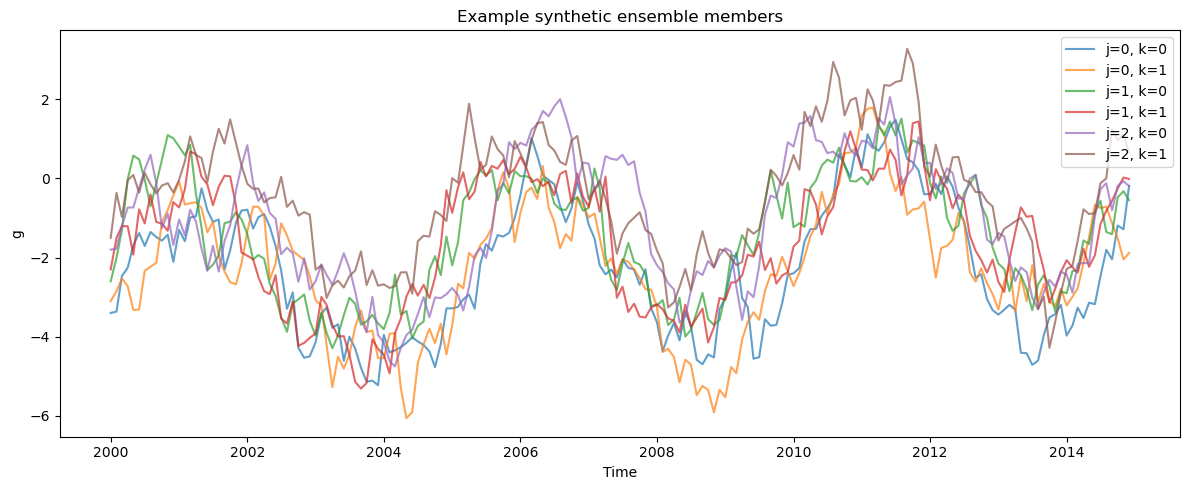

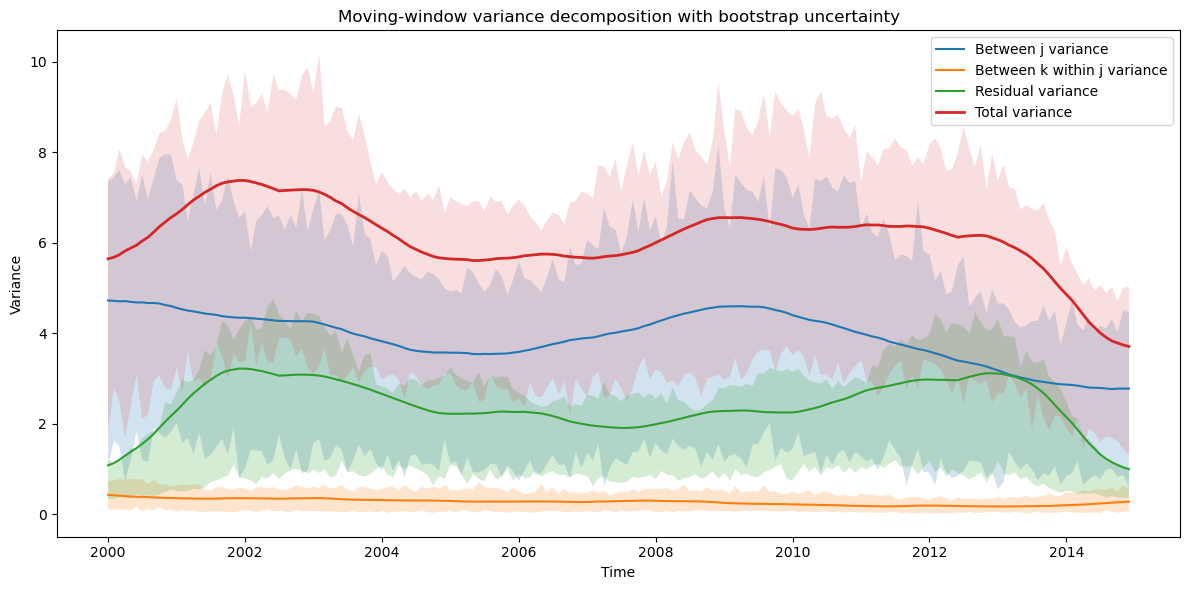

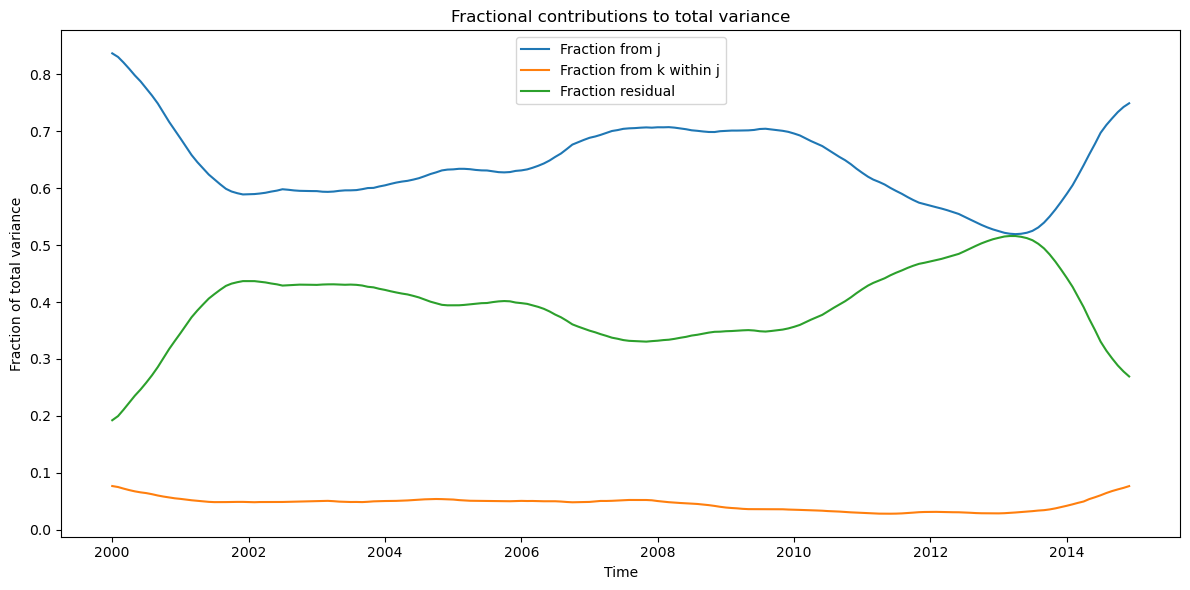


Average variance contributions
------------------------------
Mean between-j variance: 3.9165269779733354
Mean between-k-within-j variance: 0.27660246396950233
Mean residual variance: 2.418172916128198
Mean total variance: 6.116528833159189
Mean fractional contribution from j: 0.6422078396239831
Mean fractional contribution from k within j: 0.04563254412714301
Mean fractional residual contribution: 0.3932922049603488

Mean bootstrap confidence interval widths
-----------------------------------------
Between-j variance CI width: 4.8279207703355835
Between-k-within-j variance CI width: 0.46318407142794976
Residual variance CI width: 2.2247781739229255
Total variance CI width: 4.843517065154446


In [17]:

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# Generate synthetic ensemble data
# --------------------------------------------------------------
rng = np.random.default_rng(123)

nt = 180
nj = 8
nk = 5

time = pd.date_range("2000-01-01", periods=nt, freq="MS")

arr = np.zeros((nj, nk, nt))

# Shared low-frequency oscillation
shared_signal = 2.0 * np.sin(2 * np.pi * np.arange(nt) / 60)

# Slowly varying group-level signal
group_signal = np.sin(2 * np.pi * np.arange(nt) / 90)

# Artificial drift
drift = 0.01 * np.arange(nt)

for j in range(nj):
    for k in range(nk):
        x = np.zeros(nt)

        # AR(1)-style temporal persistence
        noise = rng.normal(scale=0.5, size=nt)

        for t in range(1, nt):
            x[t] = 0.8 * x[t - 1] + noise[t]

        # j-level offset varies across groups
        j_offset = 0.8 * (j - (nj - 1) / 2)

        # k-level offset varies within each j
        k_offset = 0.3 * (k - (nk - 1) / 2)

        # Add time-varying group-specific modulation
        j_time_signal = (j / nj) * group_signal

        arr[j, k, :] = (
            shared_signal
            + j_offset
            + k_offset
            + j_time_signal
            + drift
            + x
        )

g = xr.DataArray(
    arr,
    dims=["j", "k", "t"],
    coords={
        "j": np.arange(nj),
        "k": np.arange(nk),
        "t": time,
    },
    name="g",
)

print("Synthetic data shape:", g.shape)
print("Dimensions:", g.dims)
print("Time range:", str(g.t.values[0]), "to", str(g.t.values[-1]))

# --------------------------------------------------------------
# Estimate suitable window width
# --------------------------------------------------------------
window_info = estimate_window_width(
    g,
    persistence_factor=5,
    quantile=0.75,
    detrend=True,
    a=0.0,
    b=0.01 / 30.0,  # approximate conversion from monthly drift to units/day
)

print("\nPersistence diagnostics")
print("-----------------------")
print("Representative ACF timescale:",
      window_info["representative_acf"])
print("Representative MI timescale:",
      window_info["representative_mi"])
print("Dominant persistence scale:",
      window_info["dominant_persistence_scale"])
print("Recommended window width:",
      window_info["recommended_window_width"])

# --------------------------------------------------------------
# Run moving-window decomposition with bootstrap enabled
# --------------------------------------------------------------
result = moving_window_variance_decomposition_R(
    g,
    window_width=window_info["recommended_window_width"],
    detrend=True,
    a=0.0,
    b=0.01 / 30.0,
    bootstrap=True,
    n_boot=100,
    random_seed=123,
)

print("\nDataset returned by moving_window_variance_decomposition_R")
print("----------------------------------------------------------")
print(result)

print("\nDataset attributes")
print("------------------")
for key, value in result.attrs.items():
    print(f"{key}: {value}")

# --------------------------------------------------------------
# Plot raw ensemble members
# --------------------------------------------------------------
plt.figure(figsize=(12, 5))

for j in range(min(nj, 3)):
    for k in range(min(nk, 2)):
        plt.plot(
            g.t,
            g.sel(j=j, k=k),
            alpha=0.7,
            label=f"j={j}, k={k}"
        )

plt.title("Example synthetic ensemble members")
plt.xlabel("Time")
plt.ylabel("g")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Plot variance components with bootstrap confidence intervals
# --------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    result.t,
    result["variance_between_j"],
    label="Between j variance"
)

if "variance_between_j_ci_lower" in result:
    plt.fill_between(
        result.t.values,
        result["variance_between_j_ci_lower"].values,
        result["variance_between_j_ci_upper"].values,
        alpha=0.2,
    )

plt.plot(
    result.t,
    result["variance_between_k_within_j"],
    label="Between k within j variance"
)

if "variance_between_k_within_j_ci_lower" in result:
    plt.fill_between(
        result.t.values,
        result["variance_between_k_within_j_ci_lower"].values,
        result["variance_between_k_within_j_ci_upper"].values,
        alpha=0.2,
    )

plt.plot(
    result.t,
    result["residual_variance"],
    label="Residual variance"
)

if "residual_variance_ci_lower" in result:
    plt.fill_between(
        result.t.values,
        result["residual_variance_ci_lower"].values,
        result["residual_variance_ci_upper"].values,
        alpha=0.2,
    )

plt.plot(
    result.t,
    result["total_variance"],
    label="Total variance",
    linewidth=2
)

if "total_variance_ci_lower" in result:
    plt.fill_between(
        result.t.values,
        result["total_variance_ci_lower"].values,
        result["total_variance_ci_upper"].values,
        alpha=0.15,
    )

plt.title("Moving-window variance decomposition with bootstrap uncertainty")
plt.xlabel("Time")
plt.ylabel("Variance")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Plot fractional variance contributions
# --------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    result.t,
    result["fraction_variance_between_j"],
    label="Fraction from j"
)

plt.plot(
    result.t,
    result["fraction_variance_between_k_within_j"],
    label="Fraction from k within j"
)

plt.plot(
    result.t,
    result["fraction_residual_variance"],
    label="Fraction residual"
)

plt.title("Fractional contributions to total variance")
plt.xlabel("Time")
plt.ylabel("Fraction of total variance")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Summarize average variance contributions
# --------------------------------------------------------------
print("\nAverage variance contributions")
print("------------------------------")

print(
    "Mean between-j variance:",
    float(result["variance_between_j"].mean())
)

print(
    "Mean between-k-within-j variance:",
    float(result["variance_between_k_within_j"].mean())
)

print(
    "Mean residual variance:",
    float(result["residual_variance"].mean())
)

print(
    "Mean total variance:",
    float(result["total_variance"].mean())
)

print(
    "Mean fractional contribution from j:",
    float(result["fraction_variance_between_j"].mean())
)

print(
    "Mean fractional contribution from k within j:",
    float(result["fraction_variance_between_k_within_j"].mean())
)

print(
    "Mean fractional residual contribution:",
    float(result["fraction_residual_variance"].mean())
)

# --------------------------------------------------------------
# Summarize mean bootstrap interval widths
# --------------------------------------------------------------
if "variance_between_j_ci_upper" in result:
    print("\nMean bootstrap confidence interval widths")
    print("-----------------------------------------")

    print(
        "Between-j variance CI width:",
        float(
            (
                result["variance_between_j_ci_upper"]
                - result["variance_between_j_ci_lower"]
            ).mean()
        )
    )

    print(
        "Between-k-within-j variance CI width:",
        float(
            (
                result["variance_between_k_within_j_ci_upper"]
                - result["variance_between_k_within_j_ci_lower"]
            ).mean()
        )
    )

    print(
        "Residual variance CI width:",
        float(
            (
                result["residual_variance_ci_upper"]
                - result["residual_variance_ci_lower"]
            ).mean()
        )
    )

    print(
        "Total variance CI width:",
        float(
            (
                result["total_variance_ci_upper"]
                - result["total_variance_ci_lower"]
            ).mean()
        )
    )





In [18]:

import numpy as np
import pandas as pd
import xarray as xr


def make_test_time(n):
    return pd.date_range("2000-01-01", periods=n, freq="MS")


# --------------------------------------------------------------
# Test 1: constant field
# --------------------------------------------------------------
def test_constant_field():
    g = xr.DataArray(
        np.ones((3, 4, 50)),
        dims=["j", "k", "t"],
        coords={
            "j": np.arange(3),
            "k": np.arange(4),
            "t": make_test_time(50),
        },
    )

    result = moving_window_variance_decomposition_R(
        g,
        window_width=12,
    )

    assert np.allclose(result["variance_between_j"], 0.0)
    assert np.allclose(result["variance_between_k_within_j"], 0.0)
    assert np.allclose(result["residual_variance"], 0.0)
    assert np.allclose(result["total_variance"], 0.0)

    print("test_constant_field passed")


# --------------------------------------------------------------
# Test 2: only j varies
# --------------------------------------------------------------
def test_between_j_variance():
    arr = np.zeros((3, 2, 40))

    arr[0, :, :] = 0.0
    arr[1, :, :] = 10.0
    arr[2, :, :] = 20.0

    g = xr.DataArray(
        arr,
        dims=["j", "k", "t"],
        coords={
            "j": [0, 1, 2],
            "k": [0, 1],
            "t": make_test_time(40),
        },
    )

    result = moving_window_variance_decomposition_R(
        g,
        window_width=10,
    )

    assert np.all(result["variance_between_j"] > 0)
    assert np.allclose(result["variance_between_k_within_j"], 0.0)
    assert np.allclose(result["residual_variance"], 0.0)

    print("test_between_j_variance passed")


# --------------------------------------------------------------
# Test 3: only k within j varies
# --------------------------------------------------------------
def test_between_k_within_j_variance():
    arr = np.zeros((2, 2, 40))

    arr[:, 0, :] = -1.0
    arr[:, 1, :] = 1.0

    g = xr.DataArray(
        arr,
        dims=["j", "k", "t"],
        coords={
            "j": [0, 1],
            "k": [0, 1],
            "t": make_test_time(40),
        },
    )

    result = moving_window_variance_decomposition_R(
        g,
        window_width=10,
    )

    assert np.allclose(result["variance_between_j"], 0.0)
    assert np.all(result["variance_between_k_within_j"] > 0)
    assert np.allclose(result["residual_variance"], 0.0)

    print("test_between_k_within_j_variance passed")


# --------------------------------------------------------------
# Test 4: only temporal variability
# --------------------------------------------------------------
def test_temporal_variability_only():
    signal = np.sin(np.linspace(0, 4 * np.pi, 80))

    arr = np.zeros((2, 3, 80))

    for j in range(2):
        for k in range(3):
            arr[j, k, :] = signal

    g = xr.DataArray(
        arr,
        dims=["j", "k", "t"],
        coords={
            "j": [0, 1],
            "k": [0, 1, 2],
            "t": make_test_time(80),
        },
    )

    result = moving_window_variance_decomposition_R(
        g,
        window_width=12,
    )

    assert np.allclose(result["variance_between_j"], 0.0, atol=1e-10)
    assert np.allclose(
        result["variance_between_k_within_j"],
        0.0,
        atol=1e-10,
    )
    assert np.all(result["residual_variance"] > 0)

    print("test_temporal_variability_only passed")


# --------------------------------------------------------------
# Test 5: detrending removes most variance from pure trend
# --------------------------------------------------------------
def test_detrending():
    nt = 100
    tau = np.arange(nt)

    trend = 5.0 + 0.1 * tau

    arr = np.zeros((2, 2, nt))

    for j in range(2):
        for k in range(2):
            arr[j, k, :] = trend

    g = xr.DataArray(
        arr,
        dims=["j", "k", "t"],
        coords={
            "j": [0, 1],
            "k": [0, 1],
            "t": make_test_time(nt),
        },
    )

    result_no_detrend = moving_window_variance_decomposition_R(
        g,
        window_width=20,
    )

    result_detrend = moving_window_variance_decomposition_R(
        g,
        window_width=20,
        detrend=True,
        a=5.0,
        b=0.1 / 30.0,  # approximate monthly trend in units/day
    )

    mean_total_no_detrend = float(
        result_no_detrend["total_variance"].mean()
    )
    mean_total_detrend = float(
        result_detrend["total_variance"].mean()
    )

    assert mean_total_detrend < mean_total_no_detrend

    print("test_detrending passed")


# --------------------------------------------------------------
# Test 6: automatic window-width estimation
# --------------------------------------------------------------
def test_window_width_estimation():
    rng = np.random.default_rng(123)

    nt = 120
    arr = np.zeros((2, 2, nt))

    for j in range(2):
        for k in range(2):
            x = np.zeros(nt)

            for t in range(1, nt):
                x[t] = 0.8 * x[t - 1] + rng.normal(scale=0.5)

            arr[j, k, :] = x

    g = xr.DataArray(
        arr,
        dims=["j", "k", "t"],
        coords={
            "j": [0, 1],
            "k": [0, 1],
            "t": make_test_time(nt),
        },
    )

    info = estimate_window_width(g)

    assert info["recommended_window_width"] >= 3
    assert info["dominant_persistence_scale"] >= 1

    print("test_window_width_estimation passed")


# --------------------------------------------------------------
# Test 7: bootstrap runs without error
# --------------------------------------------------------------
def test_bootstrap():
    rng = np.random.default_rng(42)

    arr = rng.normal(size=(3, 4, 60))

    g = xr.DataArray(
        arr,
        dims=["j", "k", "t"],
        coords={
            "j": np.arange(3),
            "k": np.arange(4),
            "t": make_test_time(60),
        },
    )

    result = moving_window_variance_decomposition_R(
        g,
        window_width=12,
        bootstrap=False,
    )

    assert "variance_between_j" in result
    assert "total_variance" in result

    print("test_bootstrap passed")


# --------------------------------------------------------------
# Run all tests
# --------------------------------------------------------------
if __name__ == "__main__":
    test_constant_field()
    test_between_j_variance()
    test_between_k_within_j_variance()
    test_temporal_variability_only()
    test_detrending()
    test_window_width_estimation()
    test_bootstrap()

    print("All tests passed")


test_constant_field passed
test_between_j_variance passed
test_between_k_within_j_variance passed
test_temporal_variability_only passed
test_detrending passed
test_window_width_estimation passed
test_bootstrap passed
All tests passed
